# M4 — Semantic Clustering & Constitutional Models

Two complementary clustering approaches:
1. **Semantic embeddings** (voyage-law-2): constitutions as 1024-dim legal vectors → UMAP → clusters
2. **Coded dimensions**: 10 expert-coded dimensions → hierarchical clustering → typology

Key question: do semantic clusters agree with heritage groups? With coded-dimension clusters?

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
import umap

sys.path.insert(0, str(Path('..') / 'scripts'))
from figure_style import *

apply_style()

PROJECT = Path('..') if Path('../src/data.js').exists() else Path('.')

with open(PROJECT / 'src' / 'data.js') as f:
    DATA = json.loads(f.read().split('const DATA = ')[1].rstrip(';\n'))
with open(PROJECT / 'scripts' / 'post_conflict_coding.json') as f:
    pc_coding = json.load(f)

LABELS_DATA = DATA['feature_labels']

# Load embeddings
EMB_DIR = PROJECT / 'data' / 'embeddings'
const_emb = np.load(EMB_DIR / 'constitution_embeddings.npy')
const_meta = json.load(open(EMB_DIR / 'constitution_meta.json'))
preamble_emb = np.load(EMB_DIR / 'preamble_embeddings.npy')
preamble_meta = json.load(open(EMB_DIR / 'preamble_meta.json'))

# Build DataFrame
rows = []
for i, meta in enumerate(const_meta):
    fr_name = meta['country_fr']
    pc_info = pc_coding.get(fr_name, {})
    rows.append({
        'country_en': meta['country_en'],
        'country': fr_name,
        'heritage': DATA['colonial_heritage'].get(fr_name, 'other'),
        'post_conflict': pc_info.get('post_conflict', False) if isinstance(pc_info, dict) else bool(pc_info),
    })
df = pd.DataFrame(rows)

# Add coded dimensions
fm_lookup = {r['PAYS']: r for r in DATA['feature_matrix']}
for f in FEATURES:
    df[f] = df['country'].map(lambda c: fm_lookup.get(c, {}).get(f, 0))
df['total'] = df[FEATURES].sum(axis=1)

print(f'Constitution embeddings: {const_emb.shape}')
print(f'Preamble embeddings: {preamble_emb.shape}')
print(f'Countries: {len(df)}')

/home/victo/projects/africa-constitutions/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Constitution embeddings: (54, 1024)
Preamble embeddings: (49, 1024)
Countries: 54


## 1. UMAP Projection of Constitution Embeddings

/home/victo/projects/africa-constitutions/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


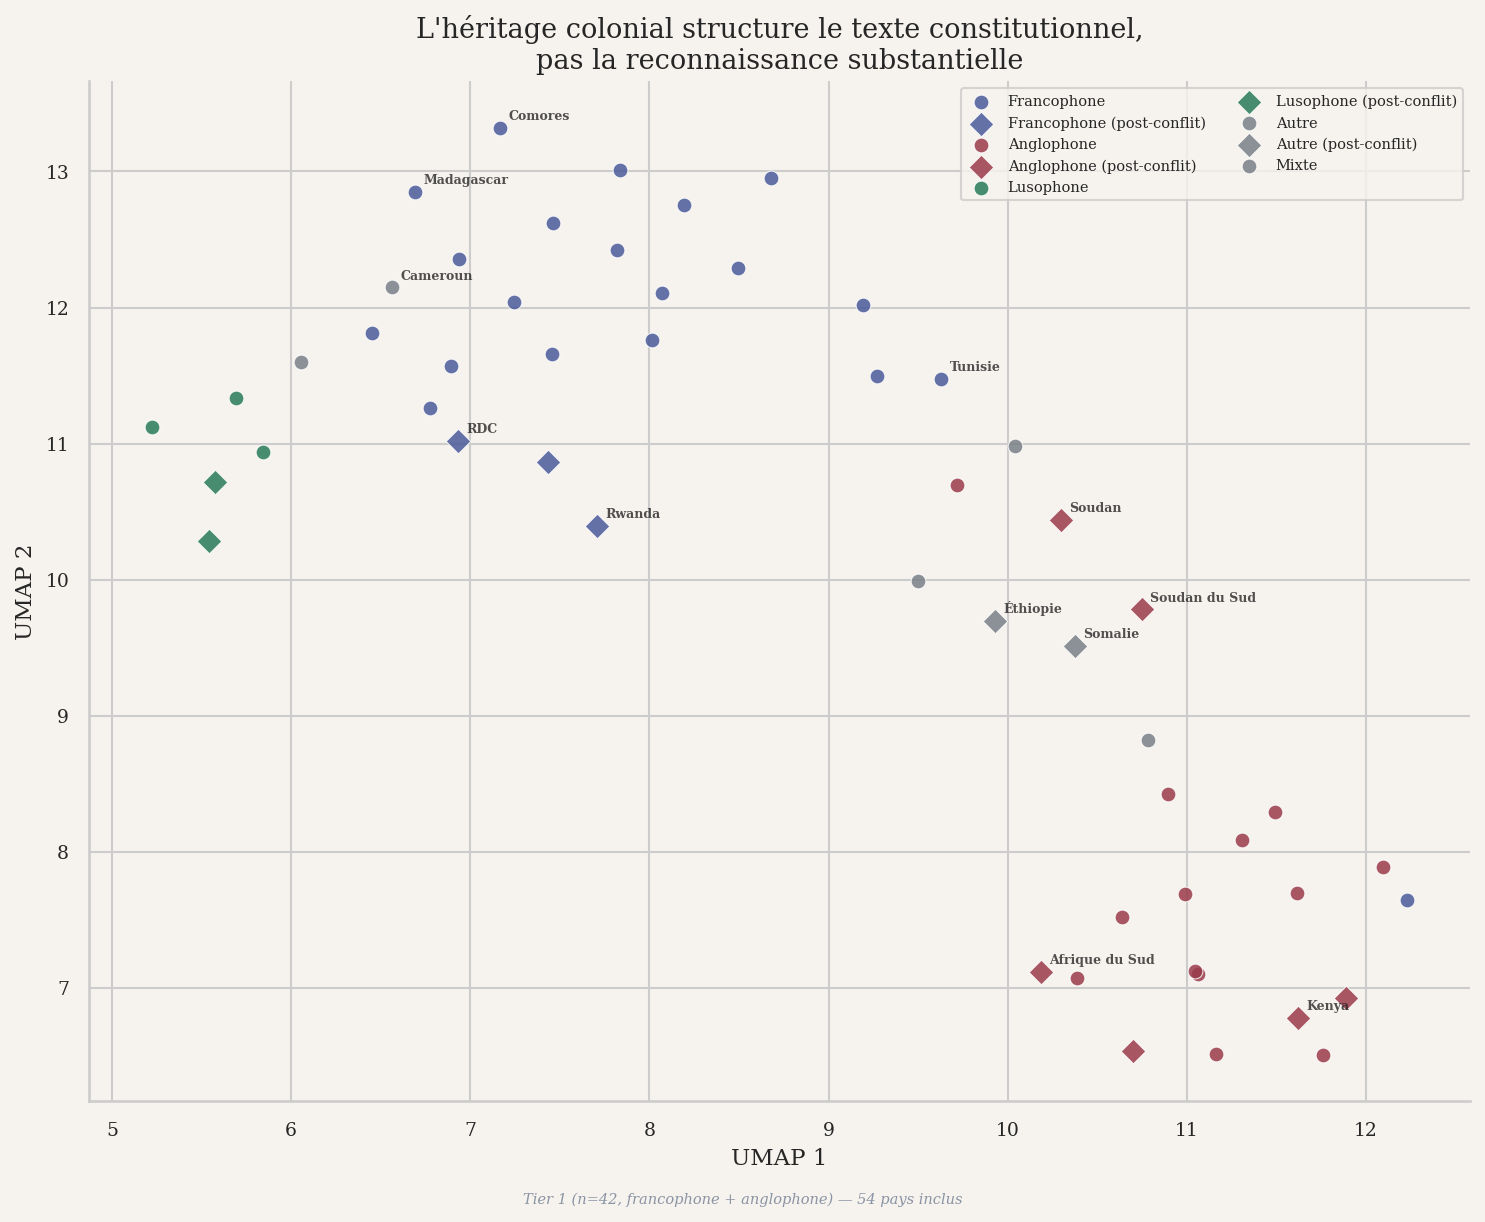

In [2]:
# UMAP projection
reducer = umap.UMAP(n_neighbors=10, min_dist=0.3, metric='cosine', random_state=42)
emb_2d = reducer.fit_transform(const_emb)
df['umap_x'] = emb_2d[:, 0]
df['umap_y'] = emb_2d[:, 1]

# Countries to always label (notable/post-conflict/outliers)
ALWAYS_LABEL = {
    'République démocratique du Congo', 'Éthiopie', 'Afrique du Sud',
    'Kenya', 'Cameroun', 'Tunisie', 'Somalie', 'Soudan du Sud',
}

# Detect isolated points: label if nearest neighbor distance > median + 1 std
from scipy.spatial.distance import cdist
dists = cdist(emb_2d, emb_2d)
np.fill_diagonal(dists, np.inf)
nn_dists = dists.min(axis=1)
isolation_threshold = np.median(nn_dists) + np.std(nn_dists)

# FIGURE: UMAP scatter — heritage colors, post-conflict shapes
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(10, 8))

    for h in H_ORDER:
        for pc in [False, True]:
            subset = df[(df['heritage'] == h) & (df['post_conflict'] == pc)]
            if len(subset) == 0: continue
            marker = 'D' if pc else 'o'
            label = hl(h, lang) + (t('post_conflict_suffix', lang) if pc else '')
            ax.scatter(subset['umap_x'], subset['umap_y'],
                      c=HC[h], s=70 if pc else 50, marker=marker,
                      alpha=0.85, edgecolors='white', linewidth=0.5, label=label)

    # Only label notable/isolated countries to avoid overlap in dense clusters
    for idx, row in df.iterrows():
        should_label = (row['country'] in ALWAYS_LABEL or
                        nn_dists[idx] > isolation_threshold)
        if should_label:
            display_name = row['country']
            if display_name == 'République démocratique du Congo':
                display_name = 'RDC'
            ax.annotate(display_name, (row['umap_x'], row['umap_y']),
                       fontsize=6, alpha=0.8, fontweight='bold',
                       xytext=(4, 4), textcoords='offset points')

    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(t('umap_const_title', lang), fontsize=13)
    ax.legend(loc='best', fontsize=7, ncol=2)

    plt.tight_layout()
    fig.text(0.5, -0.01, t('tier1_note', lang) + ' — 54 pays inclus', ha='center', fontsize=7, color=C_DIM, style='italic')
    save_fig(fig, 'clusters_umap_constitutions', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)


/home/victo/projects/africa-constitutions/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


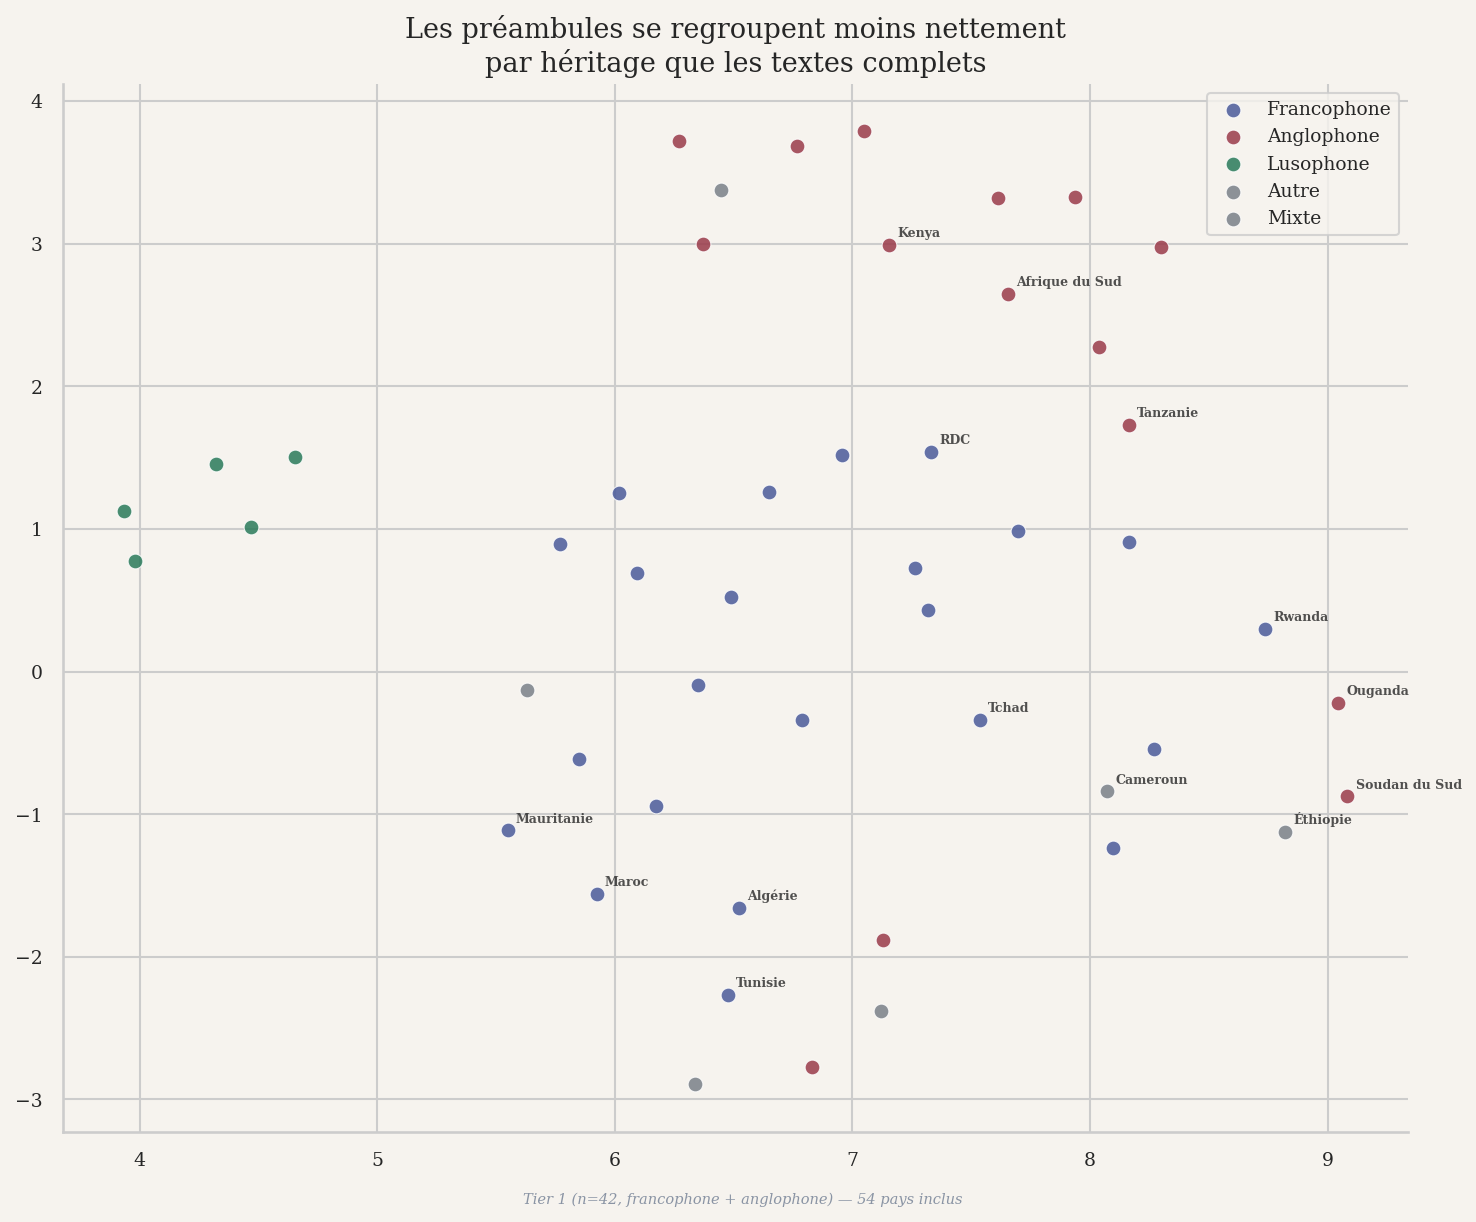

In [3]:
# Same for preambles
reducer_p = umap.UMAP(n_neighbors=8, min_dist=0.3, metric='cosine', random_state=42)
preamble_2d = reducer_p.fit_transform(preamble_emb)

# Map preamble meta to heritage
p_df = pd.DataFrame(preamble_meta)
p_df['heritage'] = p_df['country_fr'].map(lambda c: DATA['colonial_heritage'].get(c, 'other'))
p_df['post_conflict'] = p_df['country_fr'].map(lambda c: pc_coding.get(c, {}).get('post_conflict', False) if isinstance(pc_coding.get(c, {}), dict) else bool(pc_coding.get(c, False)))
p_df['umap_x'] = preamble_2d[:, 0]
p_df['umap_y'] = preamble_2d[:, 1]

# Abbreviate long country names
PREAMBLE_NAME_ABBREV = {
    'République démocratique du Congo': 'RDC',
    'République centrafricaine': 'Centrafrique',
}

# Countries to always label (notable/post-conflict/outliers) — same approach as constitutions UMAP
PREAMBLE_ALWAYS_LABEL = {
    'République démocratique du Congo', 'Éthiopie', 'Afrique du Sud',
    'Kenya', 'Cameroun', 'Tunisie', 'Somalie', 'Soudan du Sud',
}

# Detect isolated points: label if nearest neighbor distance > median + 1 std
from scipy.spatial.distance import cdist
p_dists = cdist(preamble_2d, preamble_2d)
np.fill_diagonal(p_dists, np.inf)
p_nn_dists = p_dists.min(axis=1)
p_isolation_threshold = np.median(p_nn_dists) + np.std(p_nn_dists)

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(10, 8))
    for h in H_ORDER:
        subset = p_df[p_df['heritage'] == h]
        if len(subset) == 0: continue
        ax.scatter(subset['umap_x'], subset['umap_y'],
                  c=HC[h], s=50, alpha=0.85, edgecolors='white', linewidth=0.5, label=hl(h, lang))

    # Only label notable/isolated countries to avoid overlap
    for idx_pos, (_, row) in enumerate(p_df.iterrows()):
        should_label = (row['country_fr'] in PREAMBLE_ALWAYS_LABEL or
                        p_nn_dists[idx_pos] > p_isolation_threshold)
        if should_label:
            display_name = PREAMBLE_NAME_ABBREV.get(row['country_fr'], row['country_fr'])
            ax.annotate(display_name, (row['umap_x'], row['umap_y']),
                       fontsize=6, alpha=0.8, fontweight='bold',
                       xytext=(4, 4), textcoords='offset points')

    ax.set_title(t('umap_preamb_title', lang), fontsize=13)
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.text(0.5, -0.01, t('tier1_note', lang) + ' — 54 pays inclus', ha='center', fontsize=7, color=C_DIM, style='italic')
    save_fig(fig, 'clusters_umap_preambles', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

## 2. Cross-Constitutional Similarity

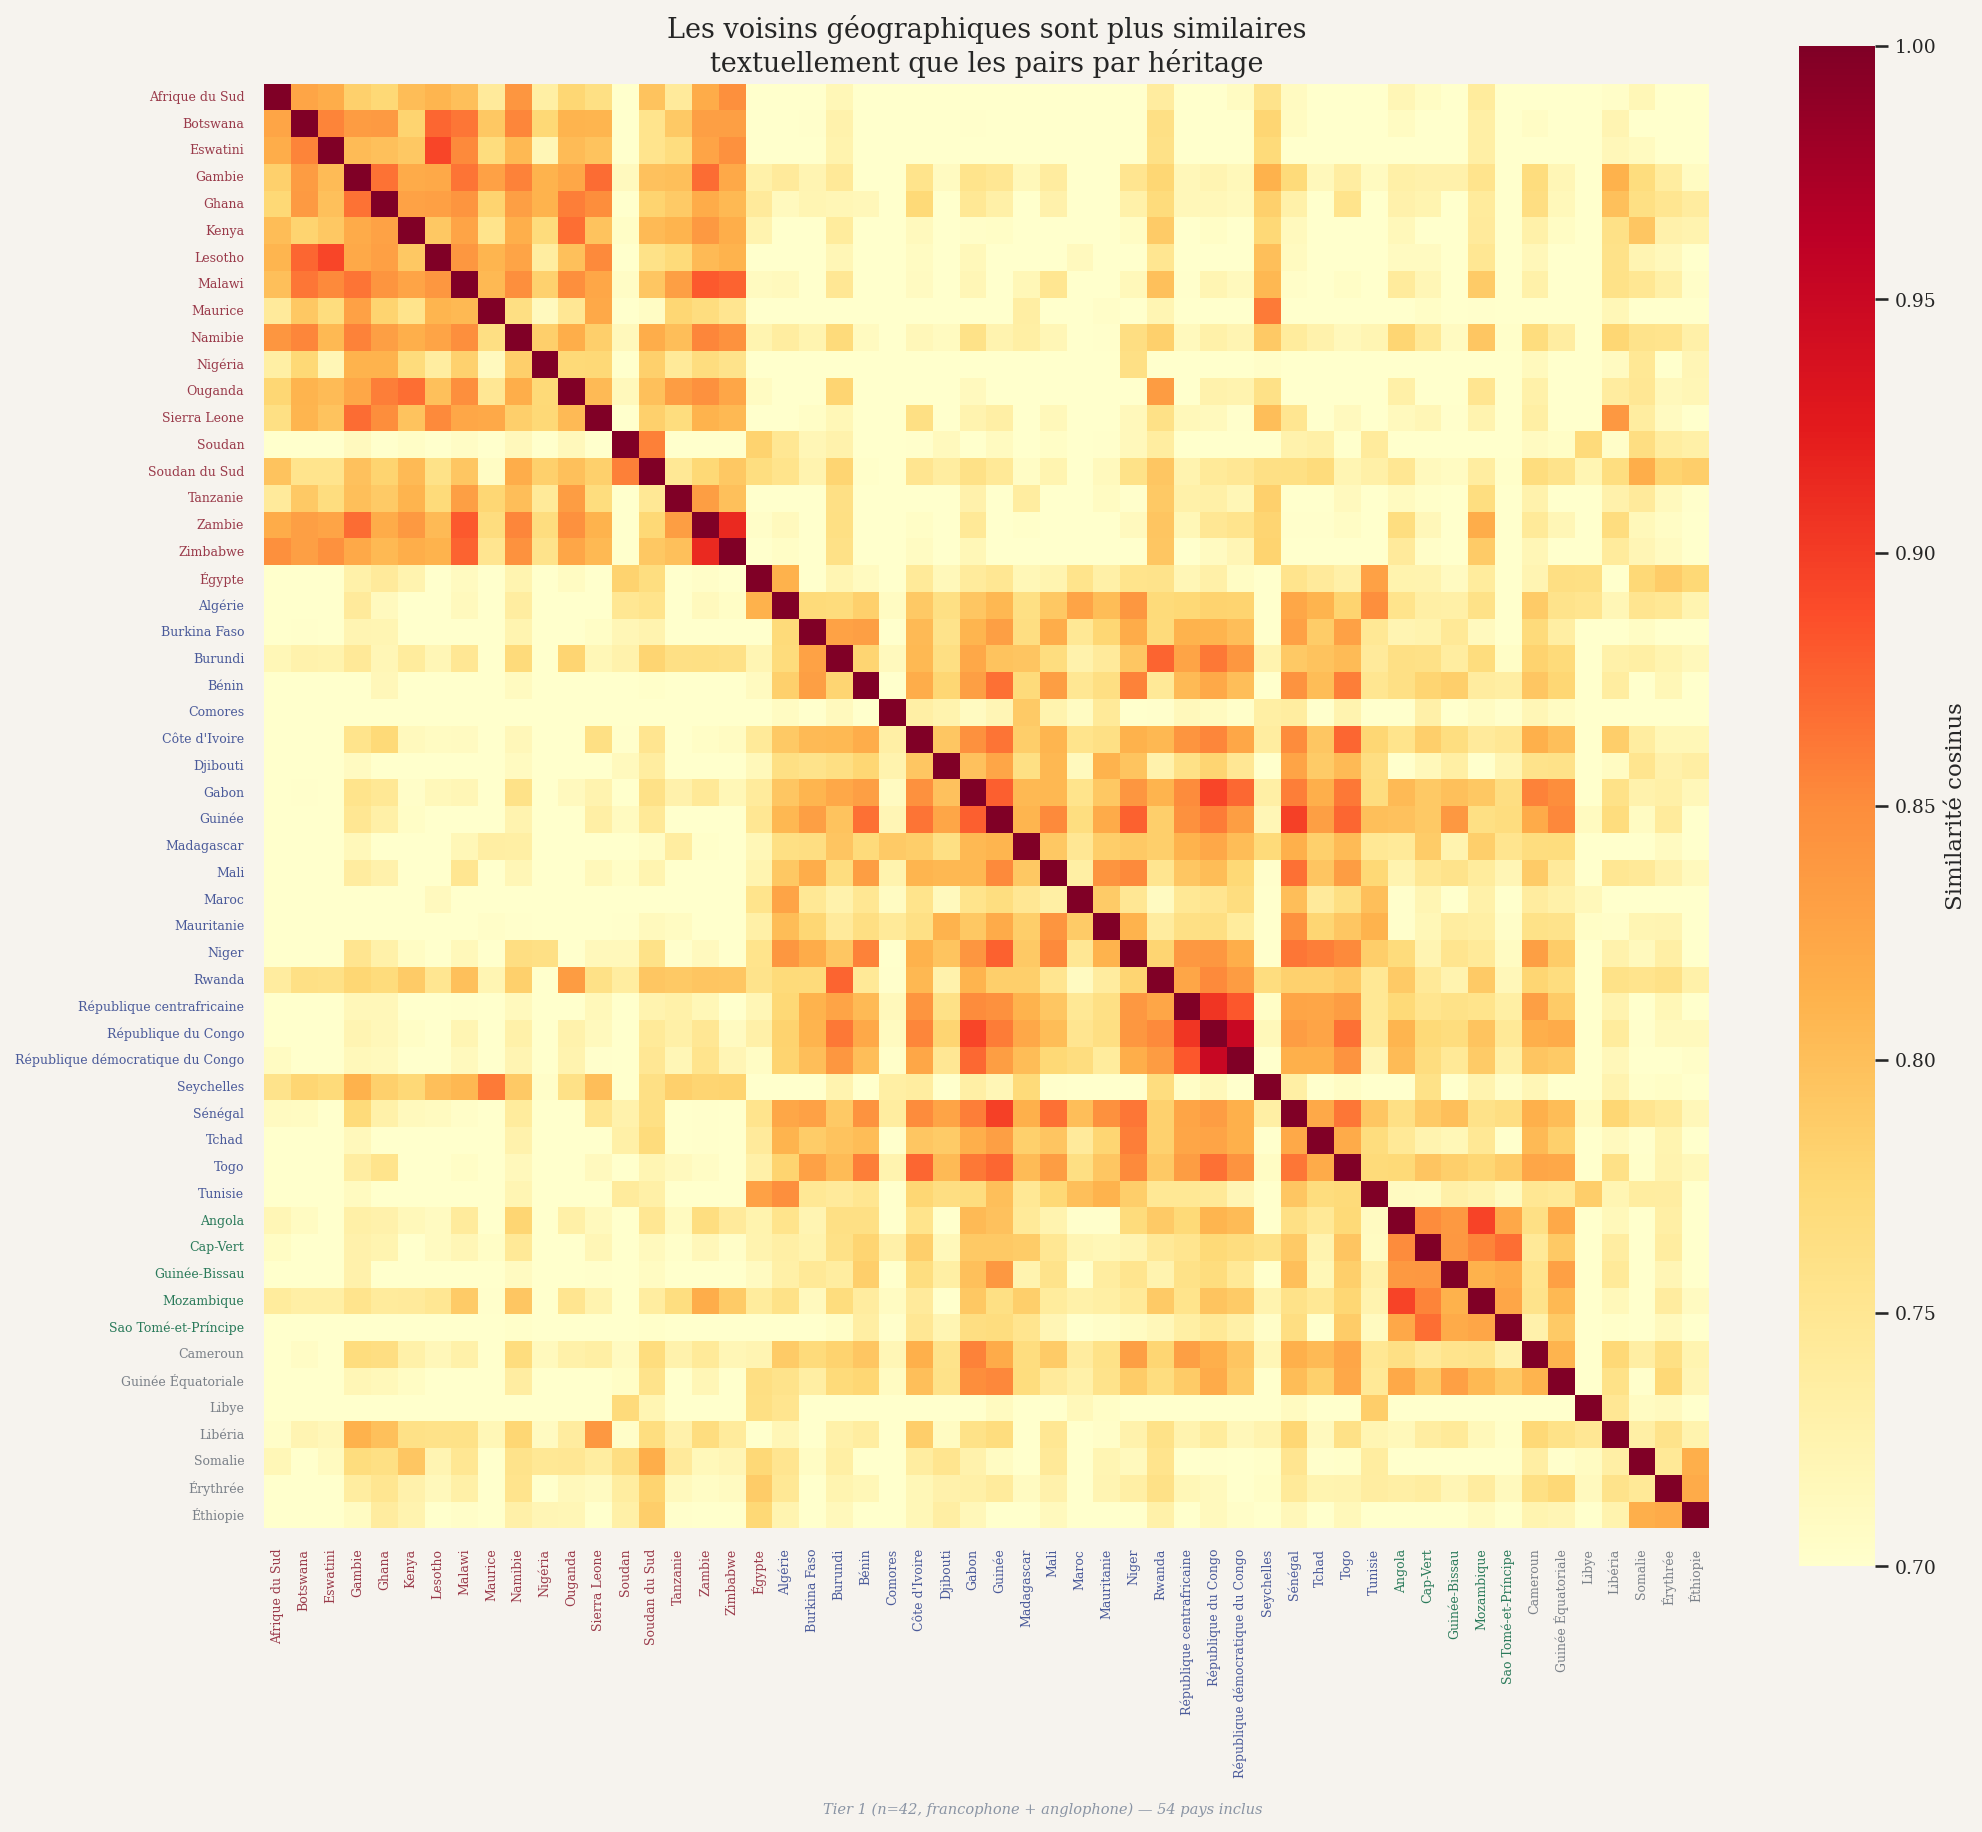

Most similar constitutions ACROSS heritage groups:
  Maurice                   [anglophone  ] <-> Seychelles                [francophone ]  sim=0.861
  Cameroun                  [mixed       ] <-> Gabon                     [francophone ]  sim=0.856
  Guinée Équatoriale        [other       ] <-> Guinée                    [francophone ]  sim=0.853
  Guinée Équatoriale        [other       ] <-> Gabon                     [francophone ]  sim=0.849
  Libéria                   [other       ] <-> Sierra Leone              [anglophone  ]  sim=0.839
  Guinée                    [francophone ] <-> Guinée-Bissau             [lusophone   ]  sim=0.839
  Rwanda                    [francophone ] <-> Ouganda                   [anglophone  ]  sim=0.835
  Cameroun                  [mixed       ] <-> République centrafricaine [francophone ]  sim=0.832
  Cameroun                  [mixed       ] <-> Niger                     [francophone ]  sim=0.832
  Guinée Équatoriale        [other       ] <-> Guinée-Biss

In [4]:
# Cosine similarity matrix
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(const_emb)

# Order by heritage
order = df.sort_values(['heritage', 'country']).index.tolist()
sim_ordered = sim_matrix[order][:, order]
labels_ordered = df.loc[order, 'country'].tolist()
colors_ordered = [HC.get(df.loc[i, 'heritage'], '#999') for i in order]

# FIGURE: Similarity heatmap
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(sim_ordered, xticklabels=labels_ordered, yticklabels=labels_ordered,
                cmap='YlOrRd', vmin=0.7, vmax=1.0, ax=ax, square=True,
                cbar_kws={'label': t('similarity_cbar', lang)})
    ax.set_title(t('similarity_title', lang), fontsize=13)

    for i, (label, color) in enumerate(zip(ax.get_yticklabels(), colors_ordered)):
        label.set_color(color)
        label.set_fontsize(6)
    for i, (label, color) in enumerate(zip(ax.get_xticklabels(), colors_ordered)):
        label.set_color(color)
        label.set_fontsize(6)

    plt.tight_layout()
    fig.text(0.5, -0.01, t('tier1_note', lang) + ' — 54 pays inclus', ha='center', fontsize=7, color=C_DIM, style='italic')
    save_fig(fig, 'clusters_similarity_heatmap', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

# Most similar pairs across heritage groups (interesting for thesis)
print('Most similar constitutions ACROSS heritage groups:')
cross_pairs = []
for i in range(len(df)):
    for j in range(i+1, len(df)):
        if df.iloc[i]['heritage'] != df.iloc[j]['heritage']:
            cross_pairs.append((df.iloc[i]['country'], df.iloc[j]['country'],
                               df.iloc[i]['heritage'], df.iloc[j]['heritage'],
                               sim_matrix[i, j]))
cross_pairs.sort(key=lambda x: -x[4])
for c1, c2, h1, h2, sim in cross_pairs[:10]:
    print(f'  {c1:25s} [{h1:12s}] <-> {c2:25s} [{h2:12s}]  sim={sim:.3f}')

## 3. Dimension-Based Clustering

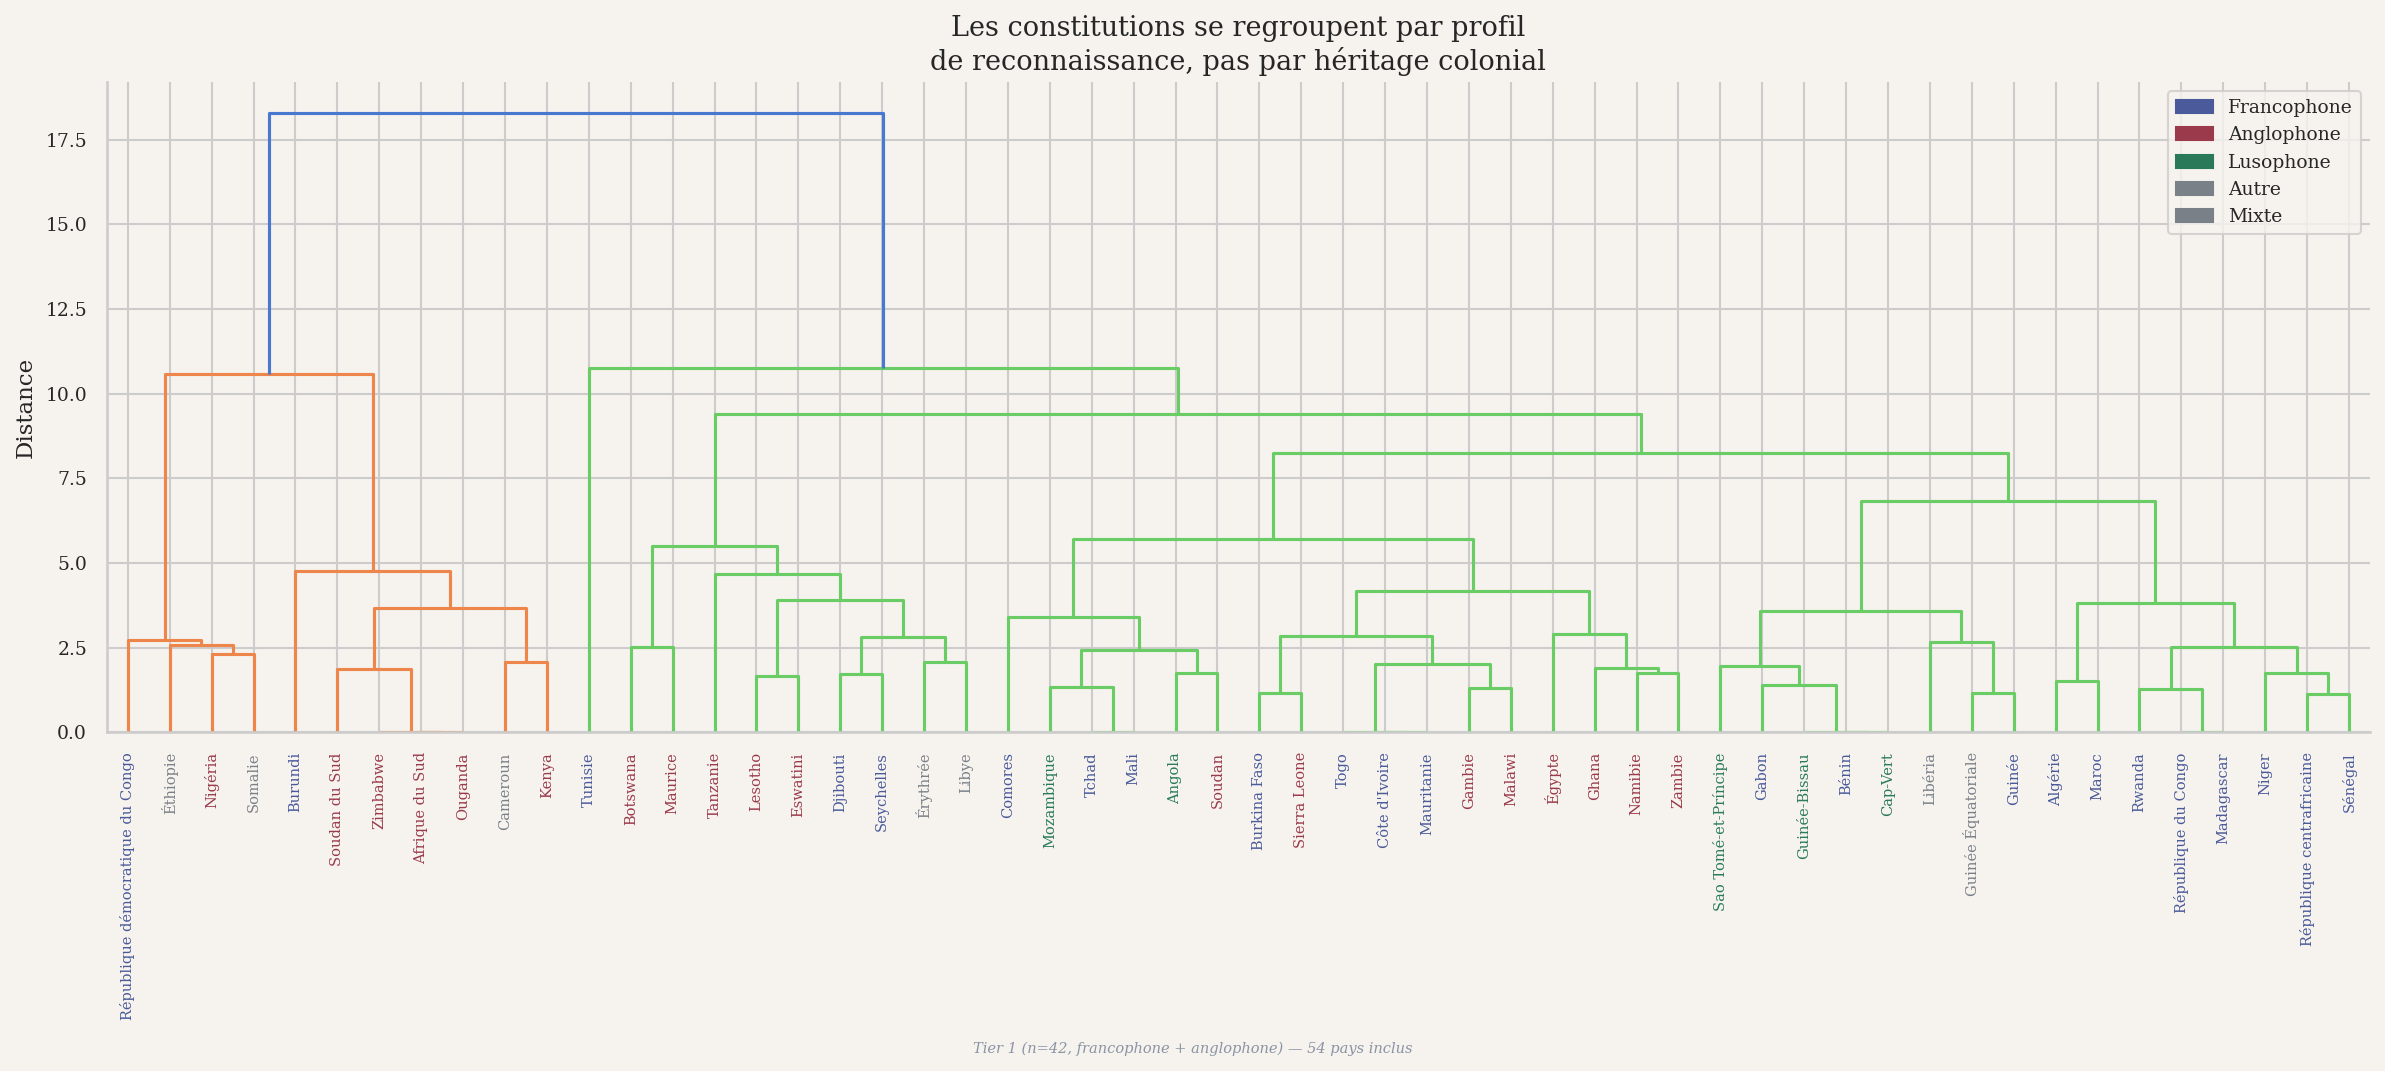

In [5]:
# Hierarchical clustering on coded dimensions
X_coded = StandardScaler().fit_transform(df[FEATURES].values)
Z = linkage(X_coded, method='ward')

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(16, 7))
    dendro = dendrogram(Z, labels=df['country'].tolist(), leaf_rotation=90, leaf_font_size=7, ax=ax)

    # Color leaves by heritage
    for lbl in ax.get_xticklabels():
        name = lbl.get_text()
        h = DATA['colonial_heritage'].get(name, 'other')
        lbl.set_color(HC.get(h, '#666'))

    ax.set_title(t('dendrogram_title', lang), fontsize=13)
    ax.set_ylabel(t('dendrogram_xlabel', lang))

    legend_patches = [mpatches.Patch(color=HC[h], label=hl(h, lang)) for h in H_ORDER]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

    plt.tight_layout()
    fig.text(0.5, -0.01, t('tier1_note', lang) + ' — 54 pays inclus', ha='center', fontsize=7, color=C_DIM, style='italic')
    save_fig(fig, 'clusters_dendrogram_dimensions', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

## 4. Embedding Clusters vs Dimension Clusters — Agreement?

In [6]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Cut both dendrograms at k=4
k = 4

# Dimension-based clusters
dim_clusters = fcluster(Z, k, criterion='maxclust')
df['dim_cluster'] = dim_clusters

# Embedding-based clusters (hierarchical on embedding space)
Z_emb = linkage(const_emb, method='average', metric='cosine')
emb_clusters = fcluster(Z_emb, k, criterion='maxclust')
df['emb_cluster'] = emb_clusters

# Heritage as integer labels
heritage_labels = df['heritage'].map({'francophone': 0, 'anglophone': 1, 'lusophone': 2, 'other': 3, 'mixed': 3}).values

# Agreement metrics
print('Cluster agreement metrics (k=4):')
print(f'  Dimension clusters ↔ Heritage:  ARI={adjusted_rand_score(heritage_labels, dim_clusters):.3f}  NMI={normalized_mutual_info_score(heritage_labels, dim_clusters):.3f}')
print(f'  Embedding clusters ↔ Heritage:  ARI={adjusted_rand_score(heritage_labels, emb_clusters):.3f}  NMI={normalized_mutual_info_score(heritage_labels, emb_clusters):.3f}')
print(f'  Dimension ↔ Embedding clusters: ARI={adjusted_rand_score(dim_clusters, emb_clusters):.3f}  NMI={normalized_mutual_info_score(dim_clusters, emb_clusters):.3f}')

print(f'\nDimension-based cluster composition:')
for c in range(1, k+1):
    members = df[df['dim_cluster'] == c]
    h_counts = members['heritage'].value_counts().to_dict()
    pc_count = members['post_conflict'].sum()
    print(f'  Cluster {c} (n={len(members)}, score={members["total"].mean():.1f}, post-conf={pc_count}): {h_counts}')

print(f'\nEmbedding-based cluster composition:')
for c in range(1, k+1):
    members = df[df['emb_cluster'] == c]
    h_counts = members['heritage'].value_counts().to_dict()
    pc_count = members['post_conflict'].sum()
    print(f'  Cluster {c} (n={len(members)}, score={members["total"].mean():.1f}, post-conf={pc_count}): {h_counts}')

Cluster agreement metrics (k=4):
  Dimension clusters ↔ Heritage:  ARI=0.033  NMI=0.111
  Embedding clusters ↔ Heritage:  ARI=0.466  NMI=0.469
  Dimension ↔ Embedding clusters: ARI=0.110  NMI=0.106

Dimension-based cluster composition:
  Cluster 1 (n=4, score=15.5, post-conf=3): {'other': 2, 'francophone': 1, 'anglophone': 1}
  Cluster 2 (n=7, score=15.7, post-conf=6): {'anglophone': 5, 'francophone': 1, 'mixed': 1}
  Cluster 3 (n=42, score=7.2, post-conf=4): {'francophone': 20, 'anglophone': 13, 'lusophone': 5, 'other': 4}
  Cluster 4 (n=1, score=3.0, post-conf=0): {'francophone': 1}

Embedding-based cluster composition:
  Cluster 1 (n=5, score=13.4, post-conf=4): {'other': 3, 'anglophone': 2}
  Cluster 2 (n=18, score=10.0, post-conf=4): {'anglophone': 16, 'other': 1, 'francophone': 1}
  Cluster 3 (n=30, score=7.4, post-conf=5): {'francophone': 21, 'lusophone': 5, 'other': 2, 'mixed': 1, 'anglophone': 1}
  Cluster 4 (n=1, score=10.0, post-conf=0): {'francophone': 1}


## 5. Summary

In [7]:
print('='*60)
print('M4 CLUSTERING SUMMARY')
print('='*60)
print(f'\nEmbeddings: {const_emb.shape[0]} constitutions × {const_emb.shape[1]} dimensions (voyage-law-2)')
print(f'Preambles: {preamble_emb.shape[0]} × {preamble_emb.shape[1]}')

ari_dim_h = adjusted_rand_score(heritage_labels, dim_clusters)
ari_emb_h = adjusted_rand_score(heritage_labels, emb_clusters)
ari_dim_emb = adjusted_rand_score(dim_clusters, emb_clusters)

print(f'\nKey finding: do clusters reproduce heritage?')
print(f'  Dimension clusters ↔ Heritage: ARI={ari_dim_h:.3f}')
print(f'  Embedding clusters ↔ Heritage: ARI={ari_emb_h:.3f}')
print(f'  (ARI=1 means perfect agreement, 0=random, negative=worse than random)')

if ari_emb_h > 0.3:
    print(f'\n  → Semantic content partially reproduces heritage groupings.')
    print(f'    Constitutions from the same colonial tradition are textually similar.')
elif ari_emb_h > 0.1:
    print(f'\n  → Weak agreement: semantic content is only loosely tied to heritage.')
    print(f'    Constitutional texts have their own structure beyond colonial origins.')
else:
    print(f'\n  → Semantic clusters do NOT reproduce heritage groups.')
    print(f'    The full text of constitutions contains structures invisible to the 10-dimension coding.')

print(f'\nFigures produced:')
for f in sorted(FIG_DIR.glob('clusters_*.pdf')):
    print(f'  {f.name}')

M4 CLUSTERING SUMMARY

Embeddings: 54 constitutions × 1024 dimensions (voyage-law-2)
Preambles: 49 × 1024

Key finding: do clusters reproduce heritage?
  Dimension clusters ↔ Heritage: ARI=0.033
  Embedding clusters ↔ Heritage: ARI=0.466
  (ARI=1 means perfect agreement, 0=random, negative=worse than random)

  → Semantic content partially reproduces heritage groupings.
    Constitutions from the same colonial tradition are textually similar.

Figures produced:
